# Exploratory Data Analysis: E-Commerce Customer Churn Prediction

This notebook provides a thorough, reproducible exploratory data analysis of the E-Commerce Customer Churn dataset.
It investigates:
- Target class distribution & imbalance
- Missing data patterns & imputation strategy
- Categorical values & synonym normalization
- Numerical feature distributions, skewness, and outliers
- Feature correlations with customer churn
- Domain behavioral feature engineering validation

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

BASE_DIR = Path("..").resolve()
sys.path.append(str(BASE_DIR))

from src.data_loader import load_data
from src.build_features import build_features, clean_categories, engineer_domain_features

sns.set_theme(style="whitegrid", palette="muted")
df_raw = load_data()
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()

Dataset Shape: 5630 rows, 20 columns


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


## 1. Target Distribution & Class Imbalance

We evaluate the distribution of the target variable `Churn` (0 = Retained, 1 = Churned).

Target Counts:
  Retained (0): 4,682 (83.16%)
  Churned (1): 948 (16.84%)


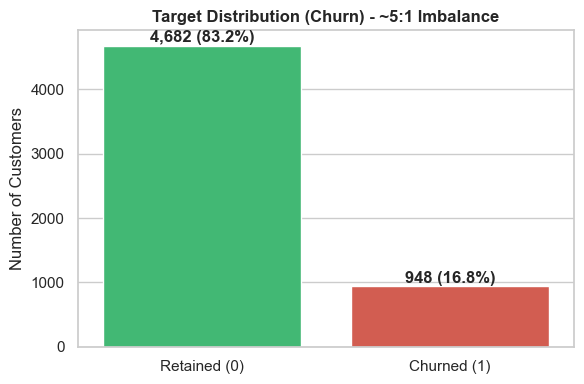

In [2]:
churn_counts = df_raw["Churn"].value_counts()
churn_pct = df_raw["Churn"].value_counts(normalize=True) * 100

print("Target Counts:")
for val in [0, 1]:
    label = "Retained (0)" if val == 0 else "Churned (1)"
    print(f"  {label}: {churn_counts[val]:,} ({churn_pct[val]:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=["Retained (0)", "Churned (1)"], y=churn_counts.values, hue=["Retained (0)", "Churned (1)"], legend=False, palette=["#2ecc71", "#e74c3c"], ax=ax)
ax.set_title("Target Distribution (Churn) - ~5:1 Imbalance", fontsize=12, fontweight="bold")
ax.set_ylabel("Number of Customers")
for i, v in enumerate(churn_counts.values):
    ax.text(i, v + 50, f"{v:,} ({churn_pct.values[i]:.1f}%)", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

**Finding:** With a positive rate of only 16.84%, accuracy is a misleading metric. Evaluation must prioritize PR-AUC (Average Precision), F1-Score, and threshold-specific Precision and Recall.

## 2. Missing Value Analysis

In [3]:
missing = df_raw.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percentage": (missing / len(df_raw)) * 100
})
missing_df

,Missing Count,Missing Percentage
DaySinceLastOrder,307,5.452931
OrderAmountHikeFromlastYear,265,4.706927
Tenure,264,4.689165
OrderCount,258,4.582593
CouponUsed,256,4.547069
HourSpendOnApp,255,4.529307
WarehouseToHome,251,4.458259


**Finding:** 7 numeric features contain missing values between 4.46% and 5.45%. A median imputer (`SimpleImputer(strategy='median')`) placed directly in the Scikit-Learn Pipeline will ensure consistent, leakage-free imputation across training and production.

## 3. Categorical Values & Synonym Cleaning

In [4]:
cat_cols = df_raw.select_dtypes("object").columns.tolist()
for col in cat_cols:
    print(f"{col} Unique Values:", df_raw[col].unique().tolist())

df_cleaned = clean_categories(df_raw)
print("\nAfter Standardization:")
for col in cat_cols:
    print(f"{col} Standardized:", df_cleaned[col].unique().tolist())

PreferredLoginDevice Unique Values: ['Mobile Phone', 'Phone', 'Computer']
PreferredPaymentMode Unique Values: ['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD', 'Credit Card']
Gender Unique Values: ['Female', 'Male']
PreferedOrderCat Unique Values: ['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']
MaritalStatus Unique Values: ['Single', 'Divorced', 'Married']

After Standardization:
PreferredLoginDevice Standardized: ['Phone', 'Computer']
PreferredPaymentMode Standardized: ['Debit Card', 'UPI', 'Credit Card', 'Cash on Delivery', 'E wallet']
Gender Standardized: ['Female', 'Male']
PreferedOrderCat Standardized: ['Laptop & Accessory', 'Mobile', 'Others', 'Fashion', 'Grocery']
MaritalStatus Standardized: ['Single', 'Divorced', 'Married']


## 4. Domain Feature Engineering Validation

In [5]:
df_engineered = engineer_domain_features(df_cleaned)
engineered_cols = ["OrderVelocity", "InactivityRatio", "PromotionDependency", "FrictionIndicator"]
df_engineered[engineered_cols].describe()

,OrderVelocity,InactivityRatio,PromotionDependency,FrictionIndicator
count,5108.000000,5059.000000,5116.000000,5630.000000
mean,0.835550,0.318396,0.609042,0.096270
std,1.344161,1.344588,0.388070,0.294987
min,0.016667,0.000000,0.000000,0.000000
25%,0.133333,0.006667,0.333333,0.000000
50%,0.333333,0.016667,0.571429,0.000000
75%,1.000000,0.044444,1.000000,0.000000
max,16.000000,46.000000,1.000000,1.000000


## 5. Correlation Analysis with Churn

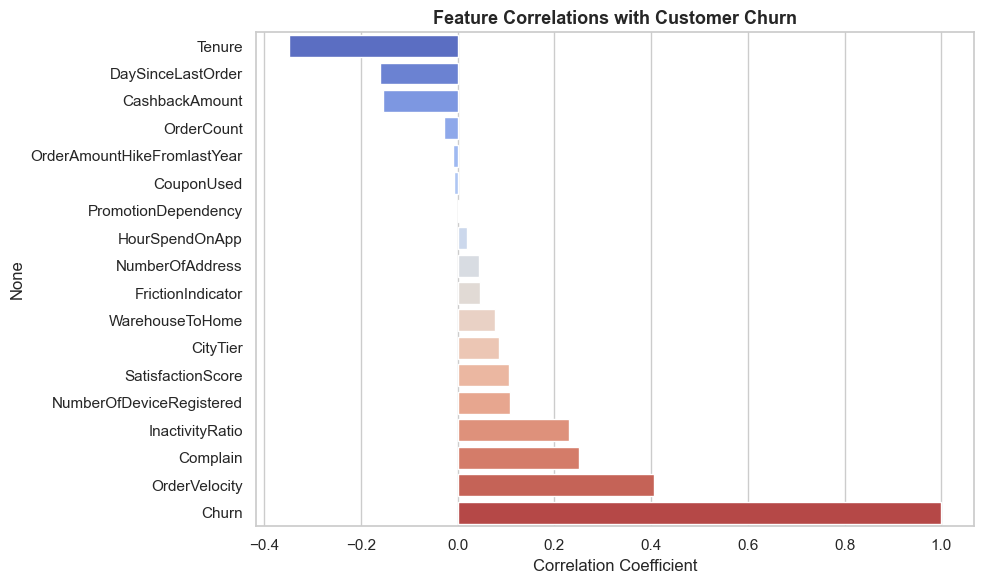

In [6]:
num_cols = df_engineered.select_dtypes(include=[np.number]).columns.tolist()
if "CustomerID" in num_cols:
    num_cols.remove("CustomerID")
corr = df_engineered[num_cols].corr()["Churn"].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=corr.values, y=corr.index, hue=corr.index, legend=False, palette="coolwarm", ax=ax)
ax.set_title("Feature Correlations with Customer Churn", fontsize=13, fontweight="bold")
ax.set_xlabel("Correlation Coefficient")
plt.tight_layout()
plt.show()

## 6. Key Insights for Modeling
1. **Strong Predictors:** `OrderVelocity` (0.41), `Tenure` (-0.35), `Complain` (0.25), and `InactivityRatio` (0.23).
2. **Domain Features Add High Signal:** `OrderVelocity` and `InactivityRatio` provide superior discriminative power over raw order count alone.
3. **Pipeline Requirements:** Incorporate `DomainFeatureEngineer`, `SimpleImputer(strategy='median')`, `StandardScaler`, and `OneHotEncoder(handle_unknown='ignore')` in a unified pipeline.